In [1]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec 
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway



import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,calculate_relative_distance_goal_ts
#from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa
from pipeline.gaze_shift_functions import *
from pipeline.oa_with_cams_plotting_funcs import *


Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [2]:
df1 = pd.read_hdf(
    r'\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\cluster_F3LILT_050725_oa.h5')

In [42]:

#session information 

session_date = '051525' 
animal_ID = 'imu3'
session_ID = 'oa_cam'
Rig_ID = 'Rig2'

#import IMU data  

imu_timestamps_path = '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) + '_control_Rig2_' + str(session_ID) + '_Ephys_BonsaiBoardTS.csv'
imu_path = '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) + '_control_Rig2_' + str(session_ID) + '_IMU.bin'

# Set up datatypes and names for each channel
dtypes = np.dtype([
    ("acc_x",np.uint16),
    ("acc_y",np.uint16),
    ("acc_z",np.uint16),
    ("none1",np.uint16),
    ("gyro_x",np.uint16),
    ("gyro_y",np.uint16),
    ("gyro_z",np.uint16),
    ("none2",np.uint16)
])


binary_in = pd.DataFrame(np.fromfile(imu_path, dtypes, -1, ''))
binary_in = binary_in.drop(columns=['none1','none2'])


# Convert to - 5V to + 5V (from ints)
data = 10 * (binary_in.astype(float)/(2**16) - 0.5)

# Downsample in time dimension
imu_samprate = 30000 # fixed constant
imu_dwnsmpl = 100 # imu_samprate is 30000, and we are using 100, therefore making it 30000/100 = 300hz. 
                  # if you want to boost up the temporal resolution up to 500hz, you can use 60.

data = data.iloc[::imu_dwnsmpl]

# Calculate new sample rate
samp_freq = imu_samprate / imu_dwnsmpl

# Alphabetize columns
data = data.reindex(sorted(data.columns), axis=1)

# Read in timestamps
csv_data = pd.read_csv(imu_timestamps_path).squeeze()
pdtime = pd.DataFrame(read_timestamp_series(csv_data))

# Get first/last timepoint, num_samples
t0 = pdtime.iloc[0,0]
num_samp = np.size(data,0)

# Samples start at t0, and are acquired at rate of
# 'ephys_sample_rate'/ 'imu_downsample'
newtime = list(np.array(t0 + np.linspace(0, num_samp-1, num_samp) / samp_freq))


IMU = ImuOrientation()

# Convert accelerometer to g
zero_reading = 2.9
sensitivity = 1.6
acc = pd.DataFrame.to_numpy((data[['acc_x', 'acc_y', 'acc_z']]-zero_reading)*sensitivity)

# Convert gyro to deg/sec
gyro = pd.DataFrame.to_numpy((data[['gyro_x', 'gyro_y', 'gyro_z']] - pd.DataFrame.mean(data[['gyro_x', 'gyro_y', 'gyro_z']]))*400)

# Collect roll & pitch
roll_pitch = np.zeros([len(acc),2])
for x in range(len(acc)):
    roll_pitch[x,:] = IMU.process((acc[x],gyro[x])) # update by row
roll_pitch = pd.DataFrame(roll_pitch, columns=['roll','pitch'])

# Collect the data together
all_data = pd.concat([
    data.reset_index(),
    pd.DataFrame(acc).reset_index(),
    pd.DataFrame(gyro).reset_index(),
    roll_pitch
], axis=1).drop(labels='index',axis=1)

# Set up column names
all_data.columns = [
    'acc_x_raw','acc_y_raw','acc_z_raw',
    'gyro_x_raw','gyro_y_raw','gyro_z_raw',
    'acc_x','acc_y','acc_z',
    'gyro_x', 'gyro_y', 'gyro_z',
    'roll', 'pitch'
]

In [ ]:
roll

Text(0.5, 0, 'frame')

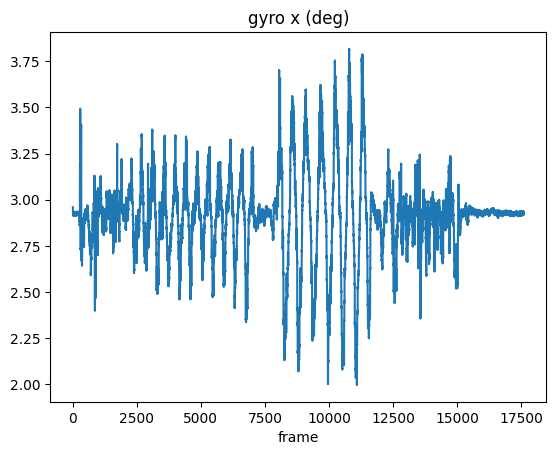

In [43]:
output_data = xr.DataArray(all_data, dims=['sample','channel'])
imu_data = output_data.assign_coords({'sample':newtime})

imuT_raw = imu_data.sample # imu timestamps

# Raw gyro values
gyro_x_raw = imu_data.sel(channel='gyro_x_raw').values
gyro_y_raw = imu_data.sel(channel='gyro_y_raw').values
gyro_z_raw = imu_data.sel(channel='gyro_z_raw').values

# Gyro values in degrees
gyro_x = imu_data.sel(channel='gyro_x').values
gyro_y = imu_data.sel(channel='gyro_y').values
gyro_z = imu_data.sel(channel='gyro_z').values

# Pitch and roll in deg
roll = imu_data.sel(channel='roll').values
pitch = imu_data.sel(channel='pitch').values

# figure of gyro z
plt.figure()
plt.plot(gyro_x_raw)
plt.title('gyro x (deg)')
plt.xlabel('frame')


Text(0.5, 0, 'samples')

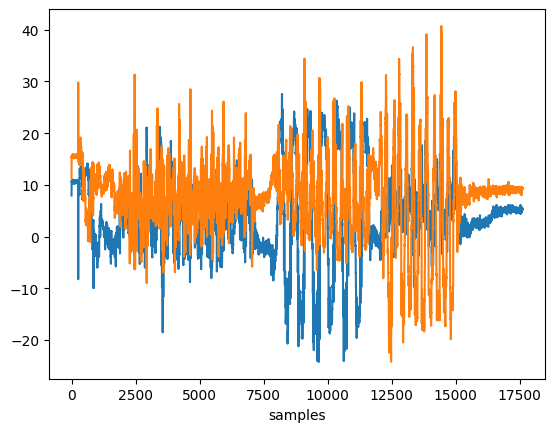

In [48]:
plt.figure()
plt.plot(roll)
plt.plot(pitch)
plt.xlabel('samples')

Text(0.5, 0, 'samples')

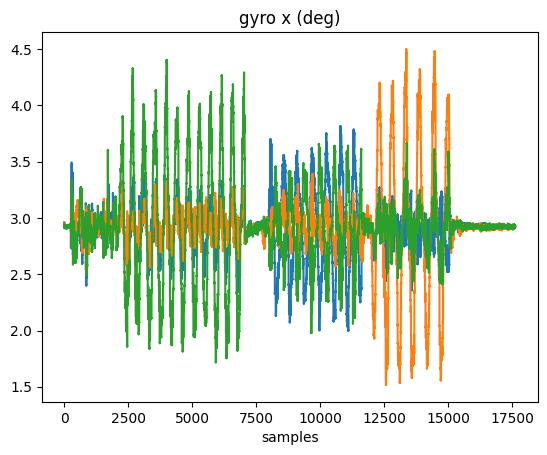

In [ ]:
plt.figure()
plt.plot(gyro_x_raw)
plt.plot(gyro_y_raw)
plt.plot(gyro_z_raw)
plt.plot
plt.title('gyro x (deg)')
plt.xlabel('samples')

Text(0.5, 0, 'samples')

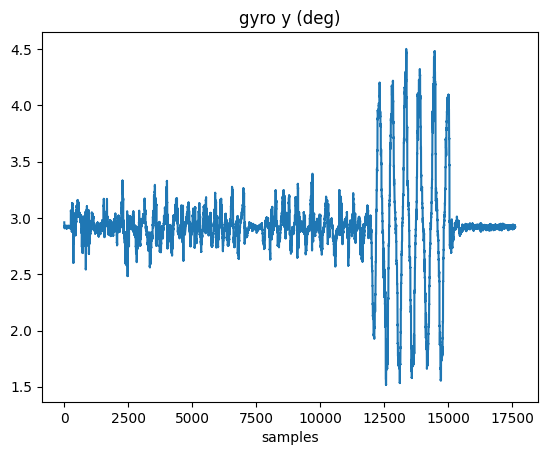

In [45]:
plt.figure()
plt.plot(gyro_y_raw)
plt.title('gyro y (deg)')
plt.xlabel('samples')


Text(0.5, 0, 'samples')

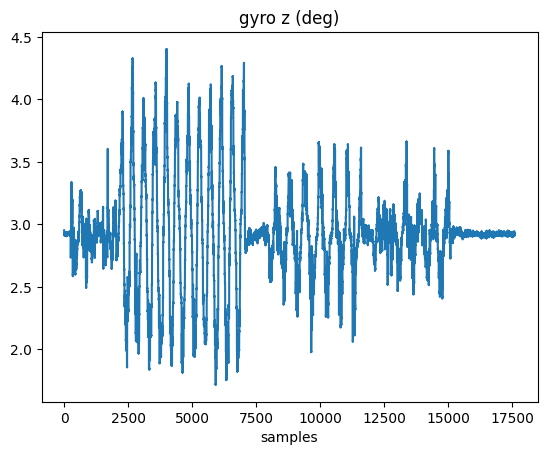

In [46]:
plt.figure()
plt.plot(gyro_z_raw)
plt.title('gyro z (deg)')
plt.xlabel('samples')


In [11]:
dlc_path = '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) +'_control_'+str(Rig_ID)+'_' + str(session_ID) + '_REYEdeinterDLC_resnet50_eye_tracking_050825May8shuffle1_1030000.h5'
eye_timestamp_path =  '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) +'_control_'+str(Rig_ID)+'_' + str(session_ID) + '_REYE_BonsaiTS.csv'

pts, pt_names = open_dlc_h5(dlc_path)
eyeT = read_timestamp_file(eye_timestamp_path, len(pts))
xrpts = xr.DataArray(pts, dims=['frame', 'point_loc'])

data = xrpts
names = list(data['point_loc'].values)
thresh = 0.99 #configuration value

x_locs = []
y_locs = []
likeli_locs = []

# seperate the lists of point names into x, y, and likelihood
for loc_num in range(0, len(names)):
    loc = names[loc_num]
    if '_x' in loc:
        x_locs.append(loc)
    elif '_y' in loc:
        y_locs.append(loc)
    elif 'likeli' in loc:
        likeli_locs.append(loc)

# get the xarray, split up into x, y,and likelihood
for loc_num in range(0, len(likeli_locs)):
    pt_loc = likeli_locs[loc_num]
    if loc_num == 0:
        likeli_pts = data.sel(point_loc=pt_loc)
    elif loc_num > 0:
        likeli_pts = xr.concat([likeli_pts, data.sel(point_loc=pt_loc)],
                                dim='point_loc', fill_value=np.nan)

for loc_num in range(0, len(x_locs)):
    pt_loc = x_locs[loc_num]
    # threshold from likelihood
    data.sel(point_loc=pt_loc)[data.sel(point_loc=pt_loc) < thresh] = np.nan
    if loc_num == 0:
        x_pts = data.sel(point_loc=pt_loc)
    elif loc_num > 0:
        x_pts = xr.concat([x_pts, data.sel(point_loc=pt_loc)],
                            dim='point_loc', fill_value=np.nan)

for loc_num in range(0, len(y_locs)):
    pt_loc = y_locs[loc_num]
    # threshold from likelihood
    data.sel(point_loc=pt_loc)[data.sel(point_loc=pt_loc) < thresh] = np.nan
    if loc_num == 0:
        y_pts = data.sel(point_loc=pt_loc)
    elif loc_num > 0:
        y_pts = xr.concat([y_pts, data.sel(point_loc=pt_loc)],
                            dim='point_loc', fill_value=np.nan)

x_pts = xr.DataArray.squeeze(x_pts)
y_pts = xr.DataArray.squeeze(y_pts)
likeli_pts = xr.DataArray.squeeze(likeli_pts)

# convert to dataframe, transpose so points are columns
x_vals = xr.DataArray.to_pandas(x_pts).T
y_vals = xr.DataArray.to_pandas(y_pts).T
likeli_vals = xr.DataArray.to_pandas(likeli_pts).T
likelihood_in = likeli_vals.values

# Subtract center of IR light reflection from points around the pupil.

spot_xcent = np.mean(x_vals.iloc[:,-5:], 1)
spot_ycent = np.mean(y_vals.iloc[:,-5:], 1)
spot_likelihood = likelihood_in[:,-5:].copy()

likelihood = likelihood_in[:,:-5]

x_vals = x_vals.iloc[:,:-5].subtract(spot_xcent, axis=0)
y_vals = y_vals.iloc[:,:-5].subtract(spot_ycent, axis=0)

x_vals = x_vals.iloc[:,:-2]
y_vals = y_vals.iloc[:,:-2]
likelihood = likelihood[:,:-2]

pupil_count = np.sum(likelihood >= thresh, 1)

spot_count = np.sum(spot_likelihood >= thresh, 1)

usegood_eye = (pupil_count >= 7) &               \
                (spot_count >= 5)

usegood_eyecalib = (pupil_count >= 8) &          \
                    (spot_count >= 5)

usegood_reflec = (spot_count >=5)


# Threshold out pts more than a given distance away from nanmean of that point
std_thresh_x = np.empty(np.shape(x_vals))

for point_loc in range(0,np.size(x_vals, 1)):
    _val = x_vals.iloc[:,point_loc]
    std_thresh_x[:,point_loc] = (np.abs(np.nanmean(_val) - _val)                \
                    / 24) > 24

std_thresh_y = np.empty(np.shape(y_vals))

for point_loc in range(0,np.size(x_vals, 1)):
    _val = y_vals.iloc[:,point_loc]
    std_thresh_y[:,point_loc] = (np.abs(np.nanmean(_val) - _val)                \
                    / 24) > 4.1

std_thresh_x = np.nanmean(std_thresh_x, 1)
std_thresh_y = np.nanmean(std_thresh_y, 1)

x_vals[std_thresh_x > 0] = np.nan
y_vals[std_thresh_y > 0] = np.nan

cols = [
    'X0',           # 0
    'Y0',           # 1
    'F',            # 2
    'a',            # 3
    'b',            # 4
    'long_axis',    # 5
    'short_axis',   # 6
    'angle_to_x',   # 7
    'angle_from_x', # 8
    'cos_phi',      # 9
    'sin_phi',      # 10
    'X0_in',        # 11
    'Y0_in',        # 12
    'phi'           # 13
]

In [12]:
#Fit ellipse

ellipse = np.empty([len(usegood_eye), 14])

# Step through each frame, fit an ellipse to points, and add ellipse
# parameters to array with data for all frames together.
linalgerror = 0
for step in tqdm(range(0,len(usegood_eye))):
    
    if usegood_eye[step] == True:
        
        try:

            e_t = fit_ellipse(x_vals.iloc[step].values,
                                    y_vals.iloc[step].values)
            
            ellipse[step] = [
                e_t['X0'],              # 0
                e_t['Y0'],              # 1
                e_t['F'],               # 2
                e_t['a'],               # 3
                e_t['b'],               # 4
                e_t['long_axis'],       # 5
                e_t['short_axis'],      # 6
                e_t['angle_to_x'],      # 7
                e_t['angle_from_x'],    # 8
                e_t['cos_phi'],         # 9
                e_t['sin_phi'],         # 10
                e_t['X0_in'],           # 11
                e_t['Y0_in'],           # 12
                e_t['phi']              # 13
            ]
        
        except np.linalg.LinAlgError as e:

            linalgerror = linalgerror + 1
            ellipse[step] = list(np.ones([len(cols)]) * np.nan)
    
    elif usegood_eye[step] == False:

        ellipse[step] = list(np.ones([len(cols)]) * np.nan)

print('LinAlg error count = ' + str(linalgerror))

# List of all places where the ellipse meets threshold
R = np.linspace(0, 2*np.pi, 100)

# (short axis / long axis) < thresh
usegood_ellipcalb = np.where((usegood_eyecalib == True)                     \
        & ((ellipse[:,6] / ellipse[:,5]) < 0.85))

# Limit number of frames used for calibration
f_lim = 50000
if np.size(usegood_ellipcalb,1) > f_lim:
    shortlist = sorted(np.random.choice(usegood_ellipcalb[0],
                        size=f_lim, replace=False))
else:
    shortlist = usegood_ellipcalb

# Find camera center
A = np.vstack([np.cos(ellipse[shortlist,7]),
                np.sin(ellipse[shortlist,7])])

b = np.expand_dims(np.diag(A.T @ np.squeeze(ellipse[shortlist, 11:13].T)), axis=1)

cam_cent = np.linalg.inv(A @ A.T) @ A @ b

# Ellipticity and scale
ellipticity = (ellipse[shortlist,6] / ellipse[shortlist,5]).T

try:
    scale = np.nansum(np.sqrt(1 - (ellipticity)**2) *                       \
    (np.linalg.norm(ellipse[shortlist, 11:13] - cam_cent.T, axis=0)))       \
    / np.sum(1 - (ellipticity)**2)

except ValueError:

    scale = np.nansum(np.sqrt(1 - (ellipticity)**2) *                       \
    (np.linalg.norm(ellipse[shortlist, 11:13] - cam_cent.T, axis=1)))       \
    / np.sum(1 - (ellipticity)**2)


# Horizontal orientation (THETA)
theta = np.arcsin((ellipse[:,11] - cam_cent[0]) / scale)

# Vertical orientation (PHI)
phi = np.arcsin((ellipse[:,12] - cam_cent[1]) / np.cos(theta) / scale)

100%|██████████| 124408/124408 [00:46<00:00, 2658.52it/s]


LinAlg error count = 0


In [13]:
# Organize data to return as an xarray of most essential parameters
ellipse_df = pd.DataFrame({
    'theta':list(theta),
    'phi':list(phi),
    'longaxis':list(ellipse[:,5]),
    'shortaxis':list(ellipse[:,6]),
    'X0':list(ellipse[:,11]),
    'Y0':list(ellipse[:,12]),
    'ellipse_phi':list(ellipse[:,7])
})

ellipse_param_names = [
    'theta',
    'phi',
    'longaxis',
    'shortaxis',
    'X0',
    'Y0',
    'ellipse_phi'
]

ellipse_out = xr.DataArray(ellipse_df,
    coords=[('frame', range(0, len(ellipse_df))),
            ('ellipse_params', ellipse_param_names)],
    dims=['frame', 'ellipse_params'])

ellipse_out.attrs['cam_center_x'] = cam_cent[0,0]
ellipse_out.attrs['cam_center_y'] = cam_cent[1,0]

In [14]:

top_dlc_path = '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) +'_control_'+str(Rig_ID)+'_' + str(session_ID) + '_TOP1DLC_resnet50_obstacle_avoidance_withcam_041825Apr18shuffle1_650000.h5'
top_timestamp_path =  '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) +'_control_'+str(Rig_ID)+'_' + str(session_ID) + '_TOP1_BonsaiTS.csv'


topT = read_timestamp_file(top_timestamp_path, len(pts))


In [15]:
shifted_head = 0
still_gaze = 120
shifted_gaze = 200

th = np.rad2deg(ellipse_out.sel(ellipse_params = 'theta').values)
theta = th - np.nanmean(th)
dEye = np.diff(theta)

In [16]:
Openephys_time = read_timestamp_file(imu_timestamps_path)
OpenephysT0 = Openephys_time[0]

# match timestamps
pts, pt_names = open_dlc_h5(dlc_path)
eyeT = read_timestamp_file(eye_timestamp_path, len(pts))
eyeT = eyeT - OpenephysT0
imuT_raw = imu_data.sample
imuT_raw = imuT_raw - OpenephysT0
topT = read_timestamp_file(top_timestamp_path, len(pts))
topT = topT - OpenephysT0

# account for the drift (it is a system known issue that open ephys box has a weird drift phenomenon)

lag_range = np.arange(-0.2, 0.2, 0.002)
cc = np.zeros(np.shape(lag_range))

t1 = np.arange(5, len(dEye)/60 - 120, 20).astype(int)
t2 = t1 + 60
offset = np.zeros(np.shape(t1))
ccmax = np.zeros(np.shape(t1))
imu_interp = scipy.interpolate.interp1d(imuT_raw, gyro_x)

for tstart in tqdm(range(len(t1))):

    for l in range(len(lag_range)):
        try:
            c, lag = nanxcorr(-dEye[t1[tstart]*60 : t2[tstart]*60],
                        imu_interp(eyeT[t1[tstart]*60 : t2[tstart]*60]+lag_range[l]),
                        1)
            cc[l] = c[1]

        except:
            cc[l] = np.nan

    offset[tstart] = lag_range[np.argmax(cc)]    
    ccmax[tstart] = np.max(cc)

offset[ccmax<0.2] = np.nan

# Fit regression to timing drift
model = sklearn.linear_model.LinearRegression()
dataT = np.array(eyeT[t1*60 + 30*60])

model.fit(dataT[~np.isnan(offset)].reshape(-1,1),
            offset[~np.isnan(offset)]) 
            
ephys_offset = model.intercept_
ephys_drift_rate = model.coef_

imuT = imuT_raw - (ephys_offset + imuT_raw * ephys_drift_rate)

tmp_eyeT = eyeT.flatten()[:-1]

# calculating eye movements

eye_use_thresh = 50
theta[np.where(abs(theta) > eye_use_thresh)] = np.nan

dEye_dps = dEye / np.diff(eyeT) # deg/sec

dEye_dps[np.where(abs(dEye_dps) >1500)] = np.nan

# Extract gaze/compensatory trials
dHead = scipy.interpolate.interp1d(imuT,
                                    gyro_x,
                                    bounds_error=False)(eyeT)[:-1]
dGaze = dHead + dEye_dps


gazeL = tmp_eyeT[(dHead > shifted_head) &         \
                 (dGaze > shifted_gaze)]
gazeR = tmp_eyeT[(dHead < -shifted_head) &        \
                 (dGaze < -shifted_gaze)]

compL = tmp_eyeT[(dHead > shifted_head) &         \
                 (dGaze < still_gaze) &           \
                 (dGaze > -still_gaze)]
compR = tmp_eyeT[(dHead < -shifted_head) &        \
                 (dGaze > -still_gaze) &          \
                 (dGaze < still_gaze)]


# Eliminating compensatory eye/head movements which fall right after gaze-shifting eye/head movements
#compL = drop_nearby_events(compL, gazeL)  
#compR = drop_nearby_events(compR, gazeR)

# Eliminate saccades repeated over sequential camera frames
gazeL_event = drop_repeat_events(gazeL)
gazeR_event = drop_repeat_events(gazeR)
compL_event = drop_repeat_events(compL)
compR_event = drop_repeat_events(compR)

# Extract idx

_, gazeL_idx, _ = np.intersect1d(tmp_eyeT,gazeL_event, return_indices=True)
_, gazeR_idx, _ = np.intersect1d(tmp_eyeT,gazeR_event, return_indices=True)
_, compL_idx, _ = np.intersect1d(tmp_eyeT,compL_event, return_indices=True)
_, compR_idx, _ = np.intersect1d(tmp_eyeT,compR_event, return_indices=True)


100%|██████████| 98/98 [01:51<00:00,  1.13s/it]


In [17]:
ccmax

array([0.28702181, 0.3106492 , 0.34149223, 0.34630573, 0.33770715,
       0.32012461, 0.32750387, 0.31947033, 0.30565442, 0.24565106,
       0.229763  , 0.23488506, 0.30190763, 0.30062896, 0.28847099,
       0.29220338, 0.31792892, 0.28257813, 0.25999519, 0.24300307,
       0.24458153, 0.27128   , 0.22528346, 0.2553839 , 0.21670037,
       0.22444298, 0.23738151, 0.23859345, 0.30797609, 0.29955336,
       0.32046624, 0.28540031, 0.29841314, 0.27084321, 0.25902282,
       0.24342689, 0.27442605, 0.25707724, 0.26874866, 0.24423607,
       0.25559577, 0.23389349, 0.29245807, 0.27213385, 0.26053952,
       0.21791597, 0.18757769, 0.21992429, 0.22110517, 0.23250391,
       0.19747612, 0.21293501, 0.23135317, 0.22778588, 0.20008431,
       0.1996047 , 0.23644628, 0.24641691, 0.2152247 , 0.22893896,
       0.23579464, 0.17552744, 0.18957259, 0.2637279 , 0.25790353,
       0.24053867, 0.21383226, 0.25987843, 0.31034453, 0.26651427,
       0.25792009, 0.24371972, 0.2882485 , 0.24038682, 0.22423

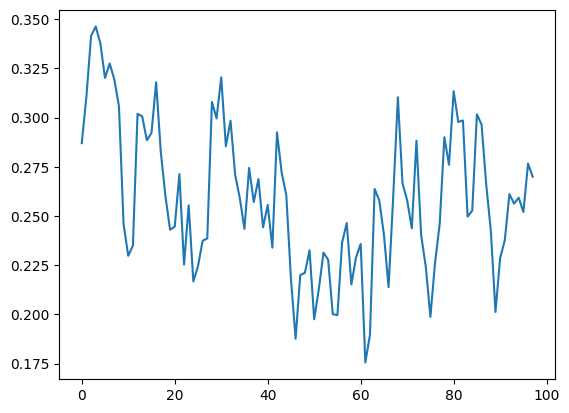

In [19]:
plt.plot(ccmax)

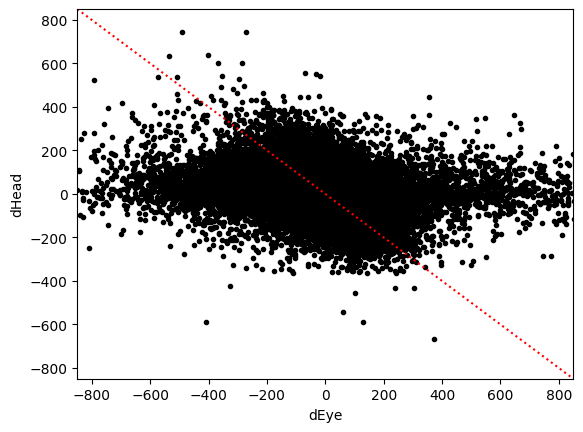

In [21]:
plt.plot(dEye_dps, dHead, 'k.')
plt.xlabel('dEye')
plt.ylabel('dHead')
plt.xlim((-850,850))
plt.ylim((-850,850))
plt.plot([-850,850], [850,-850], 'r:')